# 🍎 Apple Segmentation

## Overview
This notebook contains a computer vision exercise completed during the AI Bootcamp. The project focuses on segmenting apples from the background and estimating their count using classical image processing techniques.

## Objective
The objective of this exercise is to perform image segmentation through color space transformations, thresholding, morphological operations, and contour detection.

## Skills Practiced

- Image Segmentation
- Color Space Transformation
- Thresholding
- Morphological Operations
- Watershed Algorithm
- Contour Detection

---
**Tools:** Python, OpenCV, NumPy, Matplotlib

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6,6)

def imshow(img, title="", cmap=None):
    plt.figure()
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

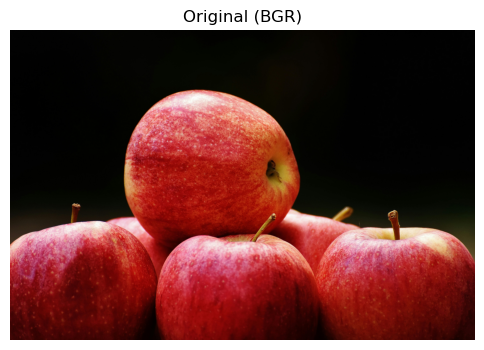

In [5]:
IMG_PATH = "fruits.jpg"
img_bgr = cv2.imread(IMG_PATH, cv2.IMREAD_COLOR)
assert img_bgr is not None, "تصویر پیدا نشد. مطمئن شوید fruits.jpg کنار نوت‌بوک است."
imshow(img_bgr, "Original (BGR)")

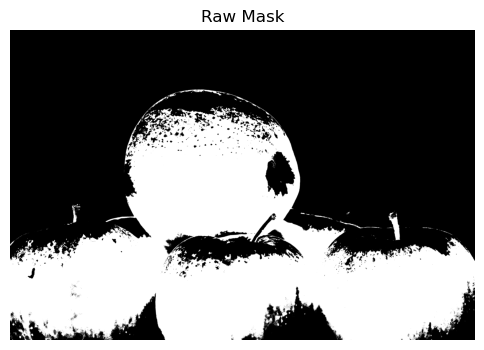

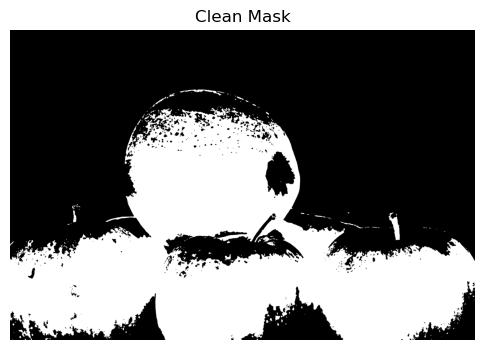

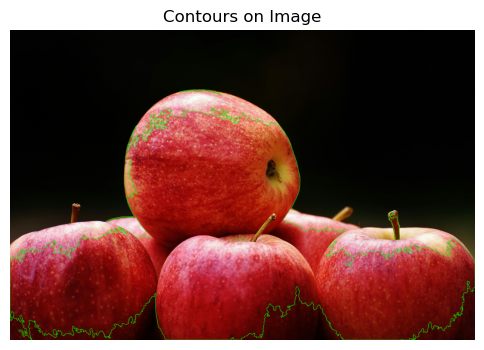

In [6]:
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

lower1 = np.array([0, 120, 70])
upper1 = np.array([10, 255, 255])

lower2 = np.array([170, 120, 70])
upper2 = np.array([180, 255, 255])

mask1 = cv2.inRange(img_hsv, lower1, upper1)
mask2 = cv2.inRange(img_hsv, lower2, upper2)
mask = cv2.bitwise_or(mask1, mask2)

kernel = np.ones((5,5), np.uint8)
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

vis = img_bgr.copy()
if len(contours) > 0:
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    cv2.drawContours(vis, contours[:3], -1, (0,255,0), 3)

imshow(mask, "Raw Mask", cmap="gray")
imshow(mask_clean, "Clean Mask", cmap="gray")
imshow(vis, "Contours on Image")

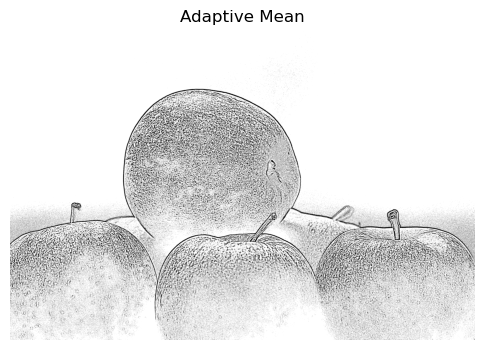

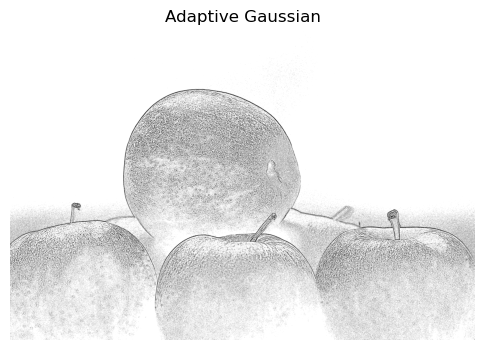

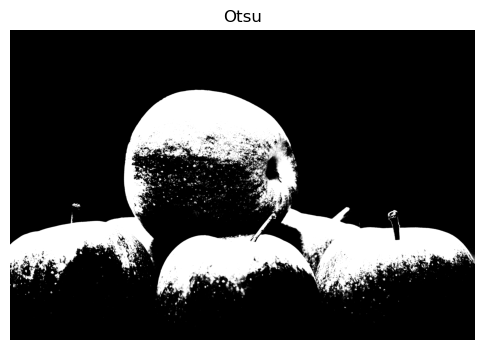

Components -> Mean: 12208 Gaussian: 4061 Otsu: 18108


In [8]:
def to_gray(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
gray = to_gray(img_bgr)

bin_mean = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    21, 5
)

bin_gauss = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    21, 5
)

otsu_val, bin_otsu = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

def count_components(binary):
    num_labels, _ = cv2.connectedComponents(binary)
    return num_labels - 1

n_mean = count_components(bin_mean)
n_gauss = count_components(bin_gauss)
n_otsu = count_components(bin_otsu)

imshow(bin_mean, "Adaptive Mean", cmap="gray")
imshow(bin_gauss, "Adaptive Gaussian", cmap="gray")
imshow(bin_otsu, "Otsu", cmap="gray")

print("Components -> Mean:", n_mean, "Gaussian:", n_gauss, "Otsu:", n_otsu)

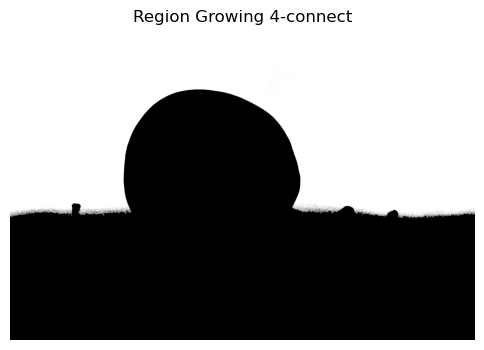

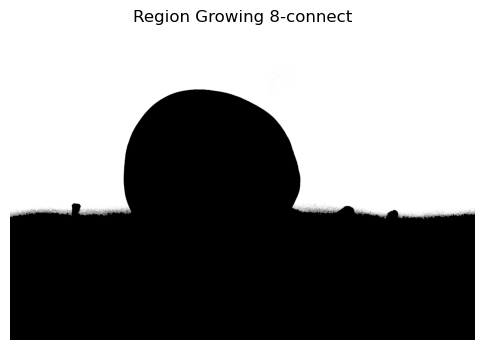

In [9]:
from collections import deque

def region_grow(gray_u8, seed_xy=(50,50), tol=15, connectivity=4):
    h, w = gray_u8.shape
    mask = np.zeros((h,w), dtype=np.uint8)
    visited = np.zeros((h,w), dtype=bool)
    
    sx, sy = seed_xy
    seed_val = int(gray_u8[sy, sx])
    
    q = deque()
    q.append((sx, sy))
    visited[sy, sx] = True
    
    if connectivity == 4:
        neighbors = [(1,0), (-1,0), (0,1), (0,-1)]
    else:
        neighbors = [(1,0), (-1,0), (0,1), (0,-1),
                     (1,1), (1,-1), (-1,1), (-1,-1)]
    
    while q:
        x, y = q.popleft()
        mask[y, x] = 255
        
        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy
            if 0 <= nx < w and 0 <= ny < h:
                if not visited[ny, nx]:
                    if abs(int(gray_u8[ny, nx]) - seed_val) <= tol:
                        q.append((nx, ny))
                        mask[ny, nx] = 255
                    visited[ny, nx] = True
    return mask

seed = (50,50)

mask_rg4 = region_grow(gray, seed, tol=15, connectivity=4)
mask_rg8 = region_grow(gray, seed, tol=15, connectivity=8)

imshow(mask_rg4, "Region Growing 4-connect", cmap="gray")
imshow(mask_rg8, "Region Growing 8-connect", cmap="gray")